Experiment - 1

Introduction : 
This problem examines the effect of using the CDF of a random variable on itself, using exponential and uniform distributions.

Methodology : Random samples were obtained from exponential and uniform distributions. The CDFs of these distributions were obtained analytically and used on the samples to create a new variable.

𝑌=𝐹𝑋(𝑋)Y=FX(X). Histograms were plotted for different sample sizes.

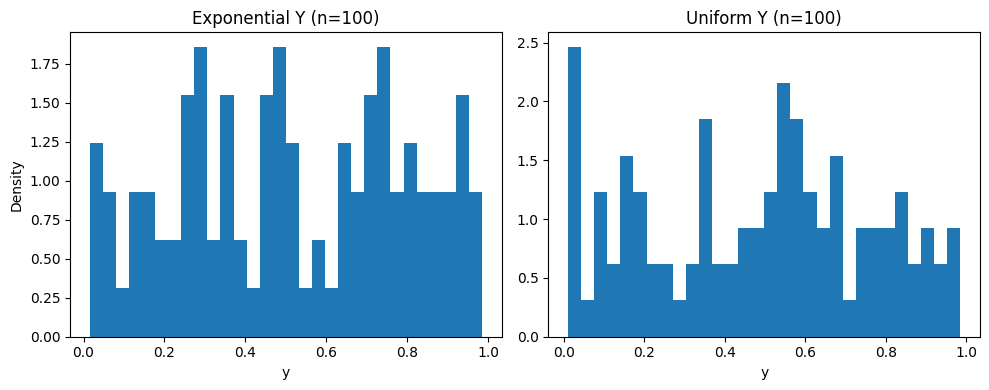

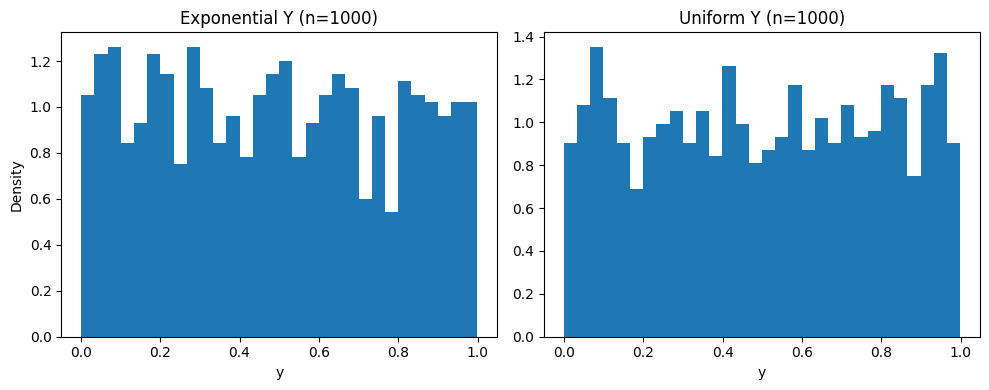

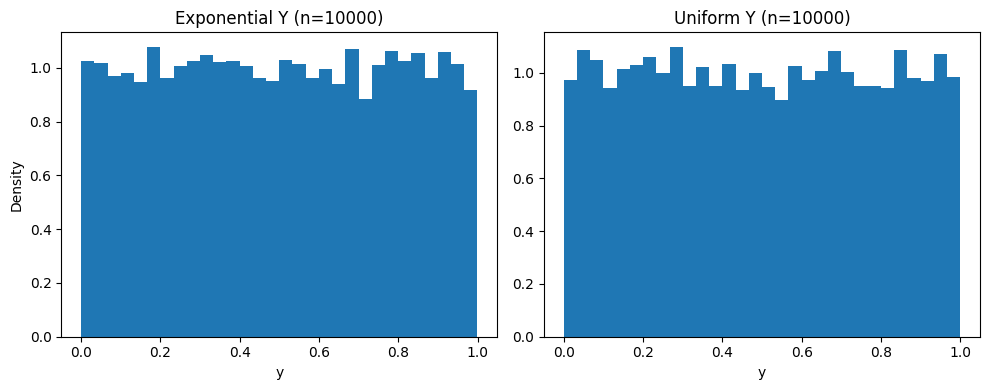

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# func to calculate the Cum. Distribtn function.
def cdf_exponential(x, lam=2):
    return 1 - np.exp(-lam * x)

def cdf_uniform(x):
    return x

sample_sizes = [100, 1000, 10000]

for n in sample_sizes:
    # Generating samples
    X_exp = np.random.exponential(scale=1/2, size=n)
    X_uni = np.random.uniform(0, 1, size=n)

    Y_exp = cdf_exponential(X_exp)
    Y_uni = cdf_uniform(X_uni)
    # Plotting histogram
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(Y_exp, bins=30, density=True)
    plt.title(f"Exponential Y (n={n})")
    plt.xlabel("y")
    plt.ylabel("Density")

    plt.subplot(1,2,2)
    plt.hist(Y_uni, bins=30, density=True)
    plt.title(f"Uniform Y (n={n})")
    plt.xlabel("y")

    plt.tight_layout()
    plt.show()


Observations and Results : 
1. Both exponential and uniform processes produce uniformly distributed Y
2. The result is independent of original distribution
3. Larger samples make the uniform nature more visible

Experiment 2

Introduction

The aim is to examine the patterns of word usage in a text and explore the impact of the transformation based on CDF on the highly skewed distribution of word frequencies in a text.

Methodology

The word frequencies were calculated after performing some basic cleaning of the text. The top 30 most frequent words were determined, the frequency CDF was calculated, and the frequencies were transformed using the CDF.

A. Count the Words

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# read text file
with open("text_file.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

# removing punctuation manually
for ch in ",.;:!?\"'()[]{}":
    text = text.replace(ch, "")

words = text.split()

# word frequency dictionary
word_count = {}
for w in words:
    word_count[w] = word_count.get(w,0) + 1

# convert to arrays
all_words = list(word_count.keys())
all_freqs = np.array(list(word_count.values()))


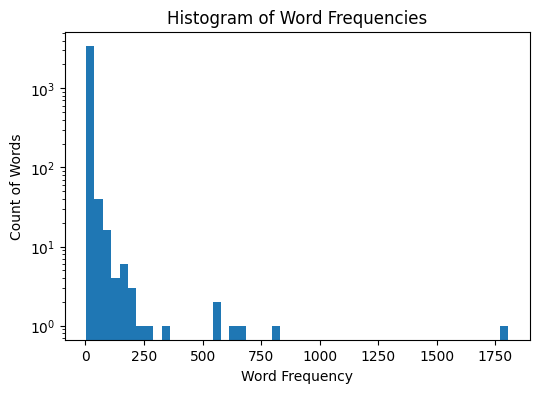

In [8]:
plt.figure(figsize=(6,4))
plt.hist(all_freqs, bins=50, log=True)
plt.xlabel("Word Frequency")
plt.ylabel("Count of Words")
plt.title("Histogram of Word Frequencies")
plt.show()


B. Focus on the Key Players:

In [4]:
# sort by frequency (descending)
sorted_items = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

top_30 = sorted_items[:30]

top_words = [w for w, f in top_30]
top_freqs = np.array([f for w, f in top_30])


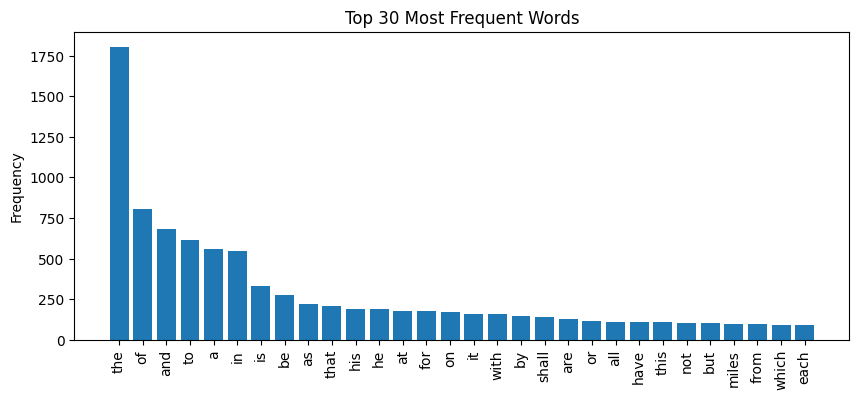

In [5]:
plt.figure(figsize=(10,4))
plt.bar(top_words, top_freqs)
plt.xticks(rotation=90)
plt.ylabel("Frequency")
plt.title("Top 30 Most Frequent Words")
plt.show()


In [6]:
sorted_freqs = np.sort(top_freqs)
n = len(sorted_freqs)

# manual CDF
cdf = np.arange(1, n+1) / n


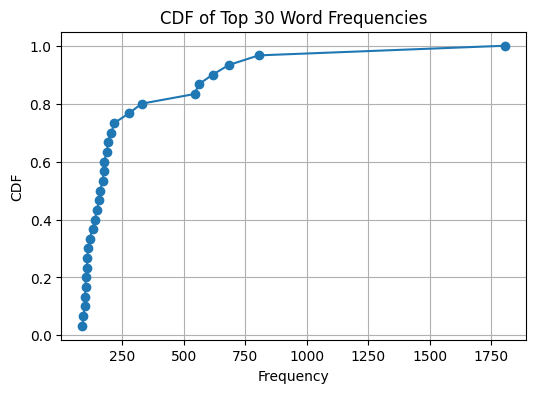

In [7]:
plt.figure(figsize=(6,4))
plt.plot(sorted_freqs, cdf, marker="o")
plt.xlabel("Frequency")
plt.ylabel("CDF")
plt.title("CDF of Top 30 Word Frequencies")
plt.grid()
plt.show()


Using this CDF as a transformation function to remap the word
frequencies

In [8]:
# map original frequencies to CDF values
freq_to_cdf = dict(zip(sorted_freqs, cdf))

transformed_freqs = np.array([freq_to_cdf[f] for f in top_freqs])


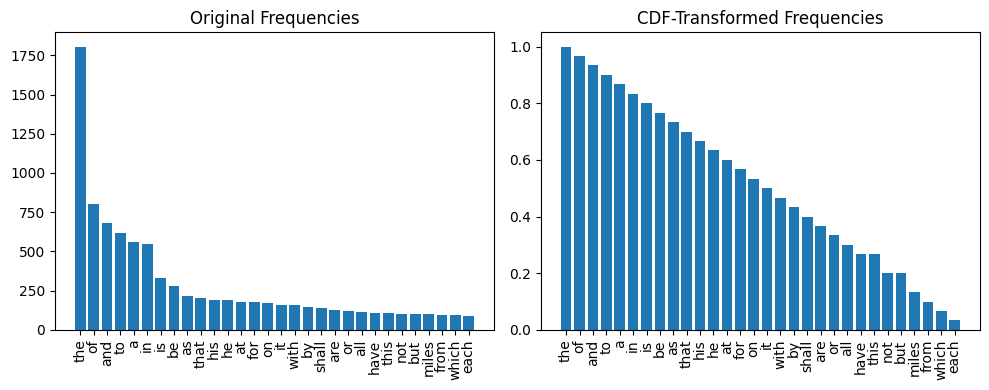

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(top_words, top_freqs)
plt.xticks(rotation=90)
plt.title("Original Frequencies")

plt.subplot(1,2,2)
plt.bar(top_words, transformed_freqs)
plt.xticks(rotation=90)
plt.title("CDF-Transformed Frequencies")

plt.tight_layout()
plt.show()


What new insights can you uncover about the text after applying this transformation?
1. Scale Normalization:
Original frequencies vary significantly
CDF transformation maps all values into [0,1]
Makes comparison easy

2. Dominance Reduction
Extremely frequent words lose dominant
Less frequent but important words become visible

3. Relative Importance 
CDF shows rank-based importance, not raw count Useful for:
Keyword extraction
Feature scaling
Text comparison across documents

4. Language Insight:
Language is not uniformly distributed
Few words carry structure
Many words carry meaning but appear less often

Conclusion :
Applying a CDF transformation to a continuous random variable transforms it into a uniform distribution.

Experiment 3

Introduction

This problem involves applying the CDF transformation technique to grayscale images to enhance contrast using histogram equalization.

Methodology

The histogram and CDF of the image were determined manually. The pixel values of the image were then converted using the histogram equalization formula.

Histogram equalization

a. Image Analysis

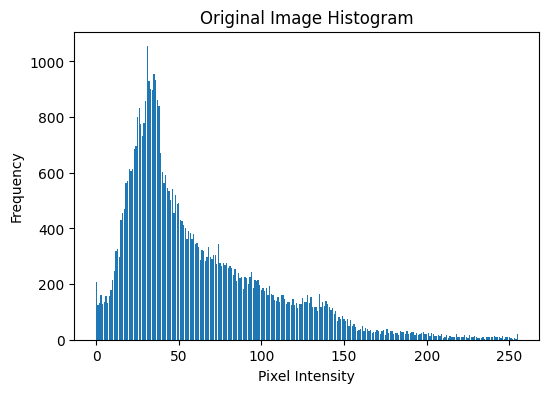

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load grayscale image
img = Image.open("dog_pic.png").convert("L")  # ensure grayscale
img_arr = np.array(img)

# Flatten image for histogram
pixels = img_arr.flatten()

# Histogram
L = 256
hist = np.zeros(L)

for p in pixels:
    hist[p] += 1

# Plot histogram
plt.figure(figsize=(6,4))
plt.bar(range(L), hist)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Original Image Histogram")
plt.show()


b. CDF Computation

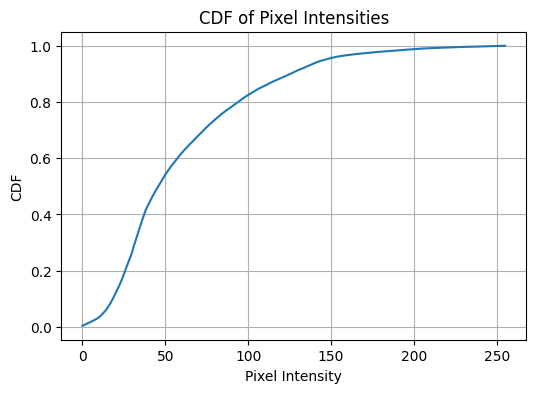

In [ ]:
# Normalizing histogram to get PDF
pdf = hist / pixels.size

# Computing CDF
cdf = np.zeros(L)
cdf[0] = pdf[0]

for i in range(1, L):
    cdf[i] = cdf[i-1] + pdf[i]

# Plot CDF
plt.figure(figsize=(6,4))
plt.plot(cdf)
plt.xlabel("Pixel Intensity")
plt.ylabel("CDF")
plt.title("CDF of Pixel Intensities")
plt.grid()
plt.show()


c. Transformation

In [ ]:
# Create transformation function
transform = np.floor((L - 1) * cdf).astype(np.uint8)

# Apply transformation
equalized_img = transform[img_arr]  # map original pixels to equalized pixels


d. Result Comparison

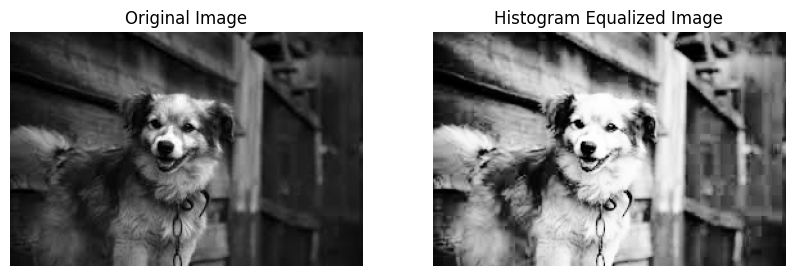

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_arr, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_img, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.show()


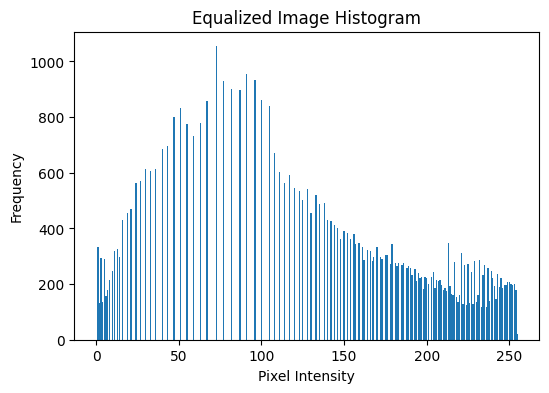

In [16]:
eq_pixels = equalized_img.flatten()
eq_hist = np.zeros(L)

for p in eq_pixels:
    eq_hist[p] += 1

plt.figure(figsize=(6,4))
plt.bar(range(L), eq_hist)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Equalized Image Histogram")
plt.show()


e. Discussion : The histogram obtained appears flat because histogram equalization is based on the CDF of the pixel intensities, which expands the more frequent intensities over a larger range and compresses the less frequent ones. This leads to a more even distribution of pixel intensities.
This is exactly what the theoretical solution to Question 1 says: if a random variable is transformed as 
𝑌=𝐹𝑋(𝑋)Y=FX(X), then the new variable has a uniform distribution. Histogram equalization is based on the same principle and expands the histogram to be close to uniform.